In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import preprocessing
%matplotlib inline

### Load Data From CSV File


In [2]:
df = pd.read_csv('rounded_values_int.csv')
df.head()

,RSRP,RSSI,RSRQ,SNR,CINR,MOS,Rounded_MOS_normal
0,-100,-74.0,-199.000000,12.762571,10.097029,4.002256,4
1,-97,-67.0,-154.000000,16.509812,13.382265,3.957574,4
2,-91,-60.0,-167.078556,17.658596,14.177795,4.011303,4
3,-103,-59.0,-175.000000,16.772214,13.420014,3.735515,4
4,-114,-87.0,-251.900407,8.051354,5.350529,3.091996,3


<div id="visualization_analysis">
    <h2>Data Visualization and Analysis</h2> 
</div>


In [3]:
df['Rounded_MOS_normal'].value_counts()

4    4936
3    1387
5     237
2      17
Name: Rounded_MOS_normal, dtype: int64

In [4]:
df.columns

Index(['RSRP', 'RSSI', 'RSRQ', 'SNR', 'CINR', 'MOS', 'Rounded_MOS_normal'], dtype='object')

In [18]:
X = df[['RSRP', 'RSSI', 'RSRQ', 'SNR', 'CINR']] .values  #.astype(float)
X[0:5]


array([[-100.        ,  -74.        , -199.        ,   12.7625705 ,
          10.09702894],
       [ -97.        ,  -67.        , -154.        ,   16.50981178,
          13.38226477],
       [ -91.        ,  -60.        , -167.07855575,   17.65859585,
          14.17779467],
       [-103.        ,  -59.        , -175.        ,   16.77221405,
          13.42001427],
       [-114.        ,  -87.        , -251.9004071 ,    8.05135392,
           5.35052915]])

In [19]:
y = df['Rounded_MOS_normal'].values
y[0:5]

array([4, 4, 4, 4, 3])

## Normalize Data


In [20]:
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X.astype(float))
X[0:5]

array([[-0.21174235, -0.58766721, -0.6732432 , -0.24031467, -0.15155846],
       [ 0.08930163,  0.24073626,  0.19851184,  0.72103402,  0.79714383],
       [ 0.69138958,  1.06913973, -0.05485032,  1.01575272,  1.02687498],
       [-0.51278632,  1.18748308, -0.20830718,  0.7883529 ,  0.80804503],
       [-1.61661423, -2.12613081, -1.69804757, -1.44896966, -1.52224094]])

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)
print(y_train[:5])

Train set: (5261, 5) (5261,)
Test set: (1316, 5) (1316,)
[4 4 4 4 4]


### now classification

In [22]:
from sklearn.neighbors import KNeighborsClassifier

### Training

In [23]:
k = 4
#Train Model and Predict  
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train,y_train)
neigh

KNeighborsClassifier(n_neighbors=4)

In [24]:
yhat = neigh.predict(X_test)
yhat[0:5]

array([3, 4, 4, 4, 3])

### Accuracy evaluation

In [25]:
from sklearn import metrics
print("Train set Accuracy: ", metrics.accuracy_score(y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(y_test, yhat))

Train set Accuracy:  0.8716973959323323
Test set Accuracy:  0.8130699088145896


In [26]:
from sklearn.metrics import f1_score


# Calculate the F1 score for different averaging methods
f1_macro = f1_score(y_test, yhat, average='macro')
f1_micro = f1_score(y_test, yhat, average='micro')
f1_weighted = f1_score(y_test, yhat, average='weighted')

print(f"F1 Score (Macro): {f1_macro:.2f}")
print(f"F1 Score (Micro): {f1_micro:.2f}")
print(f"F1 Score (Weighted): {f1_weighted:.2f}")

F1 Score (Macro): 0.39
F1 Score (Micro): 0.81
F1 Score (Weighted): 0.80


In [27]:
Ks = 10
mean_acc = np.zeros((Ks-1))
std_acc = np.zeros((Ks-1))

for n in range(1,Ks):
    
    #Train Model and Predict  
    neigh = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat=neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(y_test, yhat)

    
    std_acc[n-1]=np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

mean_acc

array([0.76443769, 0.76291793, 0.80395137, 0.81306991, 0.81762918,
       0.8275076 , 0.82674772, 0.8343465 , 0.83282675])

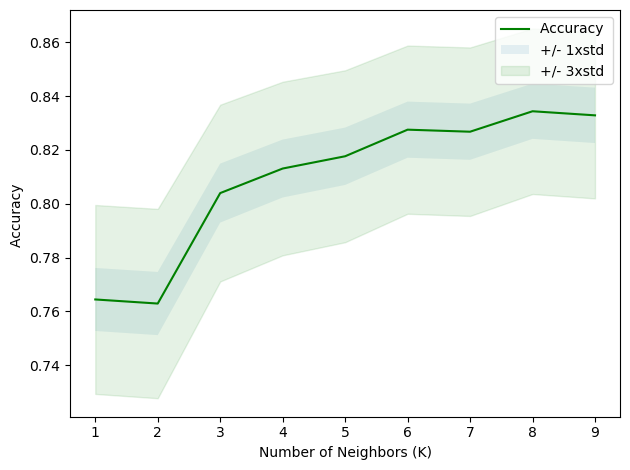

In [28]:
plt.plot(range(1,Ks),mean_acc,'g')
plt.fill_between(range(1,Ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,Ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()

In [29]:
print( "The best accuracy was with", mean_acc.max(), "with k=", mean_acc.argmax()+1) 

The best accuracy was with 0.8343465045592705 with k= 8


In [30]:
example_data=[[-113,-79.0,-241.0,12.548520203295546,9.94483747981836]]
example_normal = scaler.transform(example_data)
print(example_normal)
result = neigh.predict(example_normal)
result

[[-1.51626624 -1.17938398 -1.48688124 -0.29522893 -0.19550793]]


array([3])